### Sreeharsha Varma Tinnanuri
### MSCS-634-M20: Adavanced Big Data and Data Mining
### Lab 3: Clustering Analysis Using K-Means and K-Medoids Algorithms
### 06/14/2026

### Step 1: Load and Prepare Dataset

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, adjusted_rand_score, pairwise_distances
from sklearn.decomposition import PCA

In [14]:
# Load the Wine dataset
wine = load_wine()

X = wine.data
y = wine.target

df = pd.DataFrame(X, columns=wine.feature_names)
df['target'] = y

print("Dataset shape:", X.shape)
print("Number of classes:", len(np.unique(y)))
print("Feature names:")
print(wine.feature_names)

print("First five rows:")
display(df.head())

Dataset shape: (178, 13)
Number of classes: 3
Feature names:
['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']
First five rows:


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [15]:
# Class distribution
class_distribution = pd.Series(y).value_counts().sort_index()
class_distribution.index = [wine.target_names[i] for i in class_distribution.index]

print("Class Distribution:")
display(class_distribution.to_frame(name='count'))

Class Distribution:


,count
class_0,59
class_1,71
class_2,48


In [16]:
# Basic feature summary
feature_summary = df.drop(columns=['target']).describe().T
display(feature_summary)

,count,mean,std,min,25%,50%,75%,max
alcohol,178.0,13.000618,0.811827,11.03,12.3625,13.050,13.6775,14.83
malic_acid,178.0,2.336348,1.117146,0.74,1.6025,1.865,3.0825,5.80
ash,178.0,2.366517,0.274344,1.36,2.2100,2.360,2.5575,3.23
alcalinity_of_ash,178.0,19.494944,3.339564,10.60,17.2000,19.500,21.5000,30.00
magnesium,178.0,99.741573,14.282484,70.00,88.0000,98.000,107.0000,162.00
total_phenols,178.0,2.295112,0.625851,0.98,1.7425,2.355,2.8000,3.88
flavanoids,178.0,2.029270,0.998859,0.34,1.2050,2.135,2.8750,5.08
nonflavanoid_phenols,178.0,0.361854,0.124453,0.13,0.2700,0.340,0.4375,0.66
proanthocyanins,178.0,1.590899,0.572359,0.41,1.2500,1.555,1.9500,3.58
color_intensity,178.0,5.058090,2.318286,1.28,3.2200,4.690,6.2000,13.00


In [17]:
# Standardize the features using z-score normalization
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Confirm that standardized features have mean near 0 and standard deviation near 1
scaled_summary = pd.DataFrame(X_scaled, columns=wine.feature_names).describe().T[['mean', 'std']]
display(scaled_summary.head())

,mean,std
alcohol,7.943708e-15,1.002821
malic_acid,3.592632e-16,1.002821
ash,-4.066660e-15,1.002821
alcalinity_of_ash,-7.983626e-17,1.002821
magnesium,-7.983626e-17,1.002821


### Step 2: Implement K-Means Clustering

In [20]:
def simple_kmeans(X, k=3, max_iters=100, random_state=42):
    np.random.seed(random_state)

    # Randomly choose initial centroids
    random_indices = np.random.choice(X.shape[0], k, replace=False)
    centroids = X[random_indices]

    for _ in range(max_iters):
        # Assign each point to the nearest centroid
        distances = np.linalg.norm(X[:, np.newaxis] - centroids, axis=2)
        labels = np.argmin(distances, axis=1)

        # Compute new centroids
        new_centroids = np.array([
            X[labels == cluster].mean(axis=0)
            for cluster in range(k)
        ])

        # Stop if centroids no longer change
        if np.allclose(centroids, new_centroids):
            break

        centroids = new_centroids

    return labels, centroids

In [21]:
kmeans_labels, kmeans_centroids = simple_kmeans(X_scaled, k=3)

In [22]:
kmeans_silhouette = silhouette_score(X_scaled, kmeans_labels)
kmeans_ari = adjusted_rand_score(y, kmeans_labels)

print("Custom K-Means Results")
print("Silhouette Score:", round(kmeans_silhouette, 4))
print("Adjusted Rand Index:", round(kmeans_ari, 4))

Custom K-Means Results
Silhouette Score: 0.2849
Adjusted Rand Index: 0.8975


### Step 3: Implement K-Medoids Clustering

In [23]:
def simple_kmedoids(X, n_clusters=3, random_state=42, max_iter=300):
    # Returns labels and medoid indexes.
    rng = np.random.default_rng(random_state)
    n_samples = X.shape[0]
    
    # Compute pairwise distances once
    distances = pairwise_distances(X, metric='euclidean')
    
    # Randomly choose initial medoids
    medoid_indices = rng.choice(n_samples, size=n_clusters, replace=False)
    
    for _ in range(max_iter):
        # Assign each point to the nearest medoid
        labels = np.argmin(distances[:, medoid_indices], axis=1)
        new_medoid_indices = medoid_indices.copy()
        
        # Update each medoid by choosing the point with the lowest total distance inside the cluster
        for cluster_id in range(n_clusters):
            cluster_points = np.where(labels == cluster_id)[0]
            
            if len(cluster_points) == 0:
                # Reinitialize empty cluster medoid if needed
                new_medoid_indices[cluster_id] = rng.integers(0, n_samples)
                continue
            
            intra_cluster_distances = distances[np.ix_(cluster_points, cluster_points)]
            total_distances = intra_cluster_distances.sum(axis=1)
            best_medoid_position = np.argmin(total_distances)
            new_medoid_indices[cluster_id] = cluster_points[best_medoid_position]
        
        # Stop if medoids do not change
        if np.array_equal(np.sort(medoid_indices), np.sort(new_medoid_indices)):
            medoid_indices = new_medoid_indices
            break
        
        medoid_indices = new_medoid_indices
    
    labels = np.argmin(distances[:, medoid_indices], axis=1)
    return labels, medoid_indices

In [24]:
kmedoids_labels, medoid_indices = simple_kmedoids(X_scaled, n_clusters=3, random_state=42)

kmedoids_silhouette = silhouette_score(X_scaled, kmedoids_labels)
kmedoids_ari = adjusted_rand_score(y, kmedoids_labels)

print("K-Medoids Results")
print("Silhouette Score:", round(kmedoids_silhouette, 4))
print("Adjusted Rand Index:", round(kmedoids_ari, 4))
print("Medoid indices:", medoid_indices)

K-Medoids Results
Silhouette Score: 0.2676
Adjusted Rand Index: 0.7411
Medoid indices: [106  35 148]


### Step 4: Visualize and Compare Results

PCA was used only to project the 13-dimensional dataset into two dimensions for visualization. The clustering algorithms were trained on the full standardized dataset

In [25]:
# Reduce data to two dimensions for visualization
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total explained variance:", round(pca.explained_variance_ratio_.sum(), 4))

Explained variance ratio: [0.36198848 0.1920749 ]
Total explained variance: 0.5541


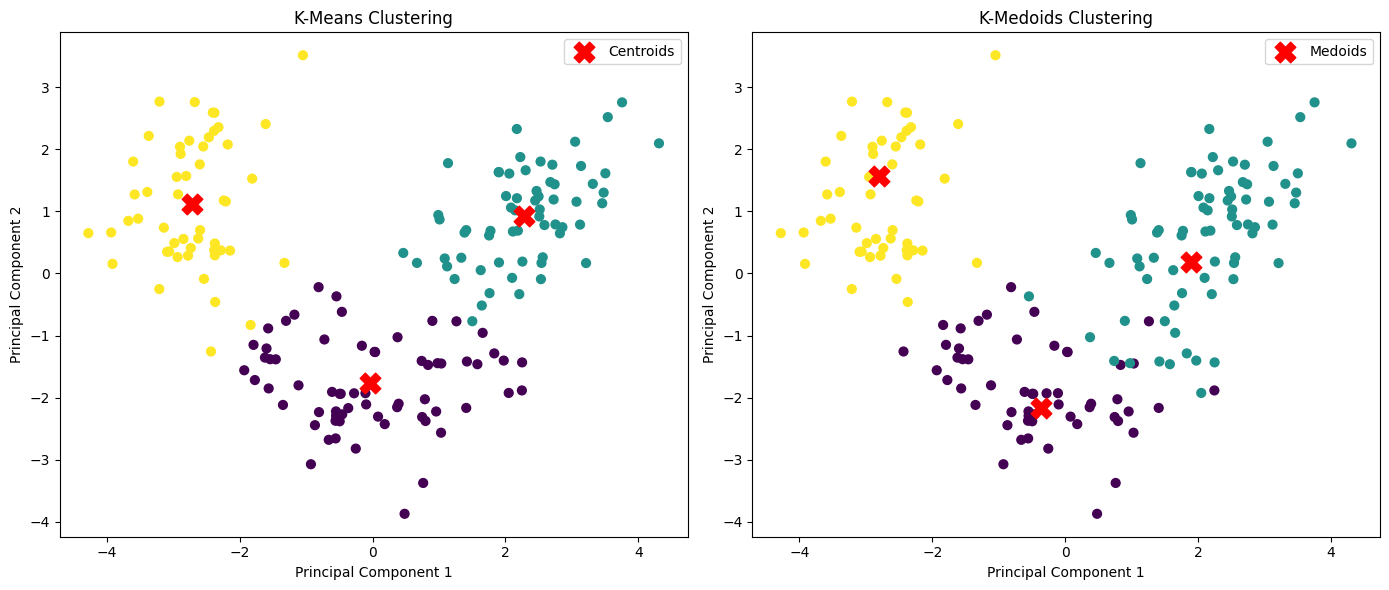

In [26]:
kmeans_centroids_pca = pca.transform(kmeans_centroids)

kmedoids_medoids_pca = X_pca[medoid_indices]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels, cmap='viridis', s=40)
axes[0].scatter(kmeans_centroids_pca[:, 0], kmeans_centroids_pca[:, 1], c='red', marker='X', s=220, label='Centroids')
axes[0].set_title('K-Means Clustering')
axes[0].set_xlabel('Principal Component 1')
axes[0].set_ylabel('Principal Component 2')
axes[0].legend()

axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=kmedoids_labels, cmap='viridis', s=40)
axes[1].scatter(kmedoids_medoids_pca[:, 0], kmedoids_medoids_pca[:, 1], c='red', marker='X', s=220, label='Medoids')
axes[1].set_title('K-Medoids Clustering')
axes[1].set_xlabel('Principal Component 1')
axes[1].set_ylabel('Principal Component 2')
axes[1].legend()

plt.tight_layout()
plt.show()

In [27]:
# Comparison Table
results = pd.DataFrame({
    'Algorithm': ['K-Means', 'K-Medoids'],
    'Silhouette Score': [kmeans_silhouette, kmedoids_silhouette],
    'Adjusted Rand Index': [kmeans_ari, kmedoids_ari]
})

display(results)

,Algorithm,Silhouette Score,Adjusted Rand Index
0,K-Means,0.284859,0.897495
1,K-Medoids,0.267622,0.741137


### Analysis

The Silhouette Score measures how well separated the clusters are. A higher value indicates that data points are closer to their own cluster and farther from neighboring clusters. The Adjusted Rand Index (ARI) compares the predicted cluster assignments with the actual wine class labels. An ARI value closer to 1 indicates stronger agreement between the clustering results and the true class labels.

Based on the results obtained in this lab, K-Means achieved a higher Silhouette Score (0.2849) than K-Medoids (0.2676), indicating that it produced more compact and well-separated clusters. K-Means also achieved a higher Adjusted Rand Index (0.8975) compared to K-Medoids (0.7411), demonstrating much better agreement with the actual wine classifications.

The PCA visualization shows that both algorithms identified similar overall groupings within the Wine dataset. However, K-Means produced more compact clusters, while K-Medoids generated slightly different cluster boundaries because it selects actual data points as the cluster centers (medoids) instead of computing the mean position of each cluster. As a result, the medoids appear slightly shifted relative to the K-Means centroids.

For this dataset, K-Means was the better-performing algorithm, producing clusters that were both more compact and more consistent with the true wine classes. K-Means is generally preferable for datasets with relatively compact, spherical clusters where computational efficiency is important. K-Medoids is more robust to outliers because cluster centers are actual observations rather than calculated means, making it a better choice for datasets containing significant noise or extreme values.